In [ ]:
!unzip /content/drive/MyDrive/gsc_mfcc_40x98.pt.zip

Archive:  /content/drive/MyDrive/gsc_mfcc_40x98.pt.zip
  inflating: content/gsc_mfcc_40x98.pt  


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm
import random

# =====================================================
# Device
# =====================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# Student Model
# =====================================================
class BestKWSStudent(nn.Module):
    def __init__(self, num_classes=12, dropout_prob=0.28):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=(40,3), stride=(1,1), padding=(0,1))
        self.bn1   = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 32, kernel_size=(1,3), stride=(1,1), padding=(0,1))
        self.bn2   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d((1,2))
        self.conv3 = nn.Conv2d(32, 64, kernel_size=(1,3), stride=(1,1), padding=(0,1))
        self.bn3   = nn.BatchNorm2d(64)
        self.dropout = nn.Dropout(dropout_prob)
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(64, num_classes)  # classifier

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.dropout(x)
        x = self.gap(x).flatten(1)  # (B,64)
        logits = self.fc(x)
        return logits

# =====================================================
# Load & Normalize Data
# =====================================================
data = torch.load("/content/content/gsc_mfcc_40x98.pt")
X_train = data["X_train"].unsqueeze(1).float()
y_train = data["y_train"]
X_val   = data["X_val"].unsqueeze(1).float()
y_val   = data["y_val"]
X_test  = data["X_test"].unsqueeze(1).float()
y_test  = data["y_test"]

mean, std = X_train.mean(), X_train.std()
X_train = (X_train - mean)/std
X_val   = (X_val   - mean)/std
X_test  = (X_test  - mean)/std

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train, y_train), batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_val, y_val), batch_size=64, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_test, y_test), batch_size=64, shuffle=False, num_workers=2, pin_memory=True
)

# =====================================================
# Model, Optimizer, Loss
# =====================================================
student = BestKWSStudent(num_classes=12).to(device)
optimizer = optim.Adam(student.parameters(), lr=8e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

# =====================================================
# Helper: Evaluation
# =====================================================
@torch.no_grad()
def evaluate(loader):
    student.eval()
    correct, total, run_loss = 0,0,0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = student(x)
        loss = criterion(logits, y)
        run_loss += loss.item()
        correct += (logits.argmax(1)==y).sum().item()
        total += y.size(0)
    return correct/total, run_loss/len(loader)

# =====================================================
# Training Loop + Early Stopping
# =====================================================
NUM_EPOCHS = 100
best_val_acc = 0.0
patience = 5
trigger = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, NUM_EPOCHS+1):
    student.train()
    run_loss = 0.0
    correct, total = 0,0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}")
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = student(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        run_loss += loss.item()
        correct  += (logits.argmax(1) == y).sum().item()
        total    += y.size(0)

        pbar.set_postfix(
            loss=f"{run_loss/(total/32):.4f}",
            acc=f"{correct/total:.4f}"
        )

    scheduler.step()
    train_acc = correct/total
    val_acc, val_loss = evaluate(val_loader)

    train_losses.append(run_loss/len(train_loader))
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch:3d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Loss: {run_loss/len(train_loader):.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(student.state_dict(), "best_student_standalone.pth")
        print(f"  ✓ Saved (val acc {val_acc:.4f})")
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            print("⚠ Early stopping triggered")
            break


# Arrays with metrics
print("Train Accs:", train_accs)
print("Val Accs:  ", val_accs)
print("Train Loss:", train_losses)
print("Val Loss:  ", val_losses)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/100:   0%|          | 0/1260 [00:00<?, ?it/s]


Epoch   1 | Train Acc: 0.5246 | Val Acc: 0.7091 | Loss: 1.4921
  ✓ Saved (val acc 0.7091)


Epoch 2/100:   0%|          | 0/1260 [00:00<?, ?it/s]


Epoch   2 | Train Acc: 0.7450 | Val Acc: 0.8006 | Loss: 0.8616
  ✓ Saved (val acc 0.8006)


...


Epoch  21 | Train Acc: 0.8968 | Val Acc: 0.8859 | Loss: 0.3366


Epoch 22/100:   0%|          | 0/1260 [00:00<?, ?it/s]


Epoch  22 | Train Acc: 0.8969 | Val Acc: 0.8899 | Loss: 0.3280


Epoch 23/100:   0%|          | 0/1260 [00:00<?, ?it/s]


Epoch  23 | Train Acc: 0.8981 | Val Acc: 0.8819 | Loss: 0.3284
⚠ Early stopping triggered
Train Accs: [0.5245966741126831, 0.745048399106478, 0.7986348969967734, 0.8244973938942666, 0.8380243236535121, 0.8489203276247208, 0.8567634648796227, 0.8610325142715314, 0.866542566393646, 0.8724249193348226, 0.8749069247952346, 0.880789277736411, 0.881831720029784, 0.8840158848349466, 0.8841648051625713, 0.888632414991313, 0.890295358649789, 0.8913129808885579, 0.8927525440555969, 0.8955323901712584, 0.8967982129560685, 0.8969471332836932, 0.8980640357408787]
Val Accs:   [0.7091428571428572, 0.8005714285714286, 0.8247619047619048, 0.8460952380952381, 0.8554285714285714, 0.8620952380952381, 0.8649523809523809, 0.8497142857142858, 0.8765714285714286, 0.8750476190476191, 0.8752380952380953, 0.8615238095238095, 0.8695238095238095, 0.8881904761904762, 0.8731428571428571, 0.8794285714285714, 0.8737142857142857, 0.8906666666666667, 0.8868571428571429, 0.8805714285714286, 0.8859047619047619, 0.8899047

In [ ]:

# =====================================================
# Test
# =====================================================
student.load_state_dict(torch.load("best_student_standalone.pth", map_location=device))
student.eval()
test_correct, test_total = 0,0
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x, y = x.to(device), y.to(device)
        preds = student(x).argmax(1)
        test_correct += (preds == y).sum().item()
        test_total += y.size(0)

print(f"\n✅ Best Validation Accuracy : {best_val_acc:.4f}")
print(f"✅ Test Accuracy            : {test_correct/test_total:.4f}")

Testing:   0%|          | 0/83 [00:00<?, ?it/s]


✅ Best Validation Accuracy : 0.8907
✅ Test Accuracy            : 0.8945


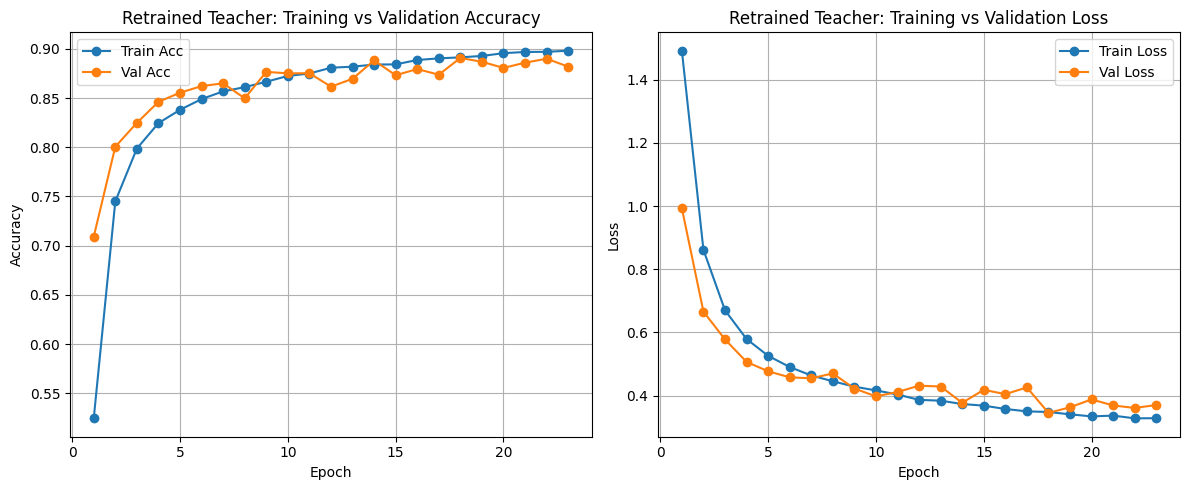

In [ ]:
import matplotlib.pyplot as plt

# Epoch numbers
epochs = range(1, len(train_accs) + 1)

epochs = range(1, len(train_accs) + 1)

plt.figure(figsize=(12, 5))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accs, label='Train Acc', marker='o')
plt.plot(epochs, val_accs, label='Val Acc', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Retrained Teacher: Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Retrained Teacher: Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Macro F1 Score: 0.8997

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       455
           1       0.88      0.86      0.87       369
           2       0.92      0.89      0.91       389
           3       0.95      0.83      0.89       484
           4       0.87      0.86      0.86       377
           5       0.82      0.96      0.88       393
           6       0.96      0.93      0.94       379
           7       0.93      1.00      0.97       300
           8       0.89      0.93      0.91       387
           9       0.84      0.84      0.84       824
          10       0.91      0.87      0.89       430
          11       0.95      0.95      0.95       481

    accuracy                           0.89      5268
   macro avg       0.90      0.90      0.90      5268
weighted avg       0.90      0.89      0.89      5268



<Figure size 1000x800 with 0 Axes>

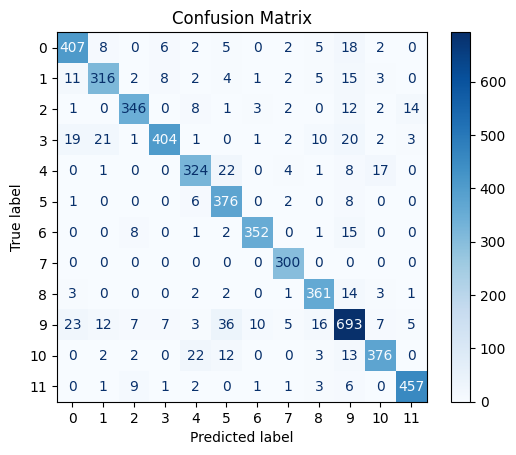

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

# =====================================================
# Load best model
# =====================================================
student.load_state_dict(torch.load("best_student_standalone.pth"))
student.eval()

# =====================================================
# Collect predictions
# =====================================================
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = student(x)

        preds = logits.argmax(dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

# =====================================================
# F1 Score
# =====================================================
f1 = f1_score(all_labels, all_preds, average='macro')
print(f"Macro F1 Score: {f1:.4f}")

# Optional detailed report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# =====================================================
# Confusion Matrix
# =====================================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix")
plt.show()